# 1) Setup
Import dependencies and set deterministic seeds.

In [33]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "appdev_options").is_dir()), cwd)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from appdev_options import config
from appdev_options.backtest import run_backtest
from appdev_options.data_loader import load_tickers
from appdev_options.dataset import walk_forward_split
from appdev_options.evaluate import (
    calibration_curve,
    plot_distribution_snapshot,
    plot_pnl,
    plot_probability_vs_actual,
    plot_realized_vs_predicted_returns,
    prepare_option_outcomes,
)
from appdev_options.features import apply_normalizer, engineer_features, fit_normalizer
from appdev_options.inference import run_inference
from appdev_options.options_filter import generate_signals
from appdev_options.train import train_model

config.set_seed(config.SEED)
pd.set_option("display.max_columns", 200)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2) Load OHLCV Data
Download daily data for configured tickers.

In [22]:
raw_data = load_tickers(
    tickers=config.TICKERS,
    start=config.TRAIN_START,
    end=config.TEST_END,
)

list(raw_data.keys())

['SPY', 'AAPL', 'MSFT', 'QQQ']

# 3) Engineer Features And Normalize
Build leak-safe features and fit normalization on train window only.

In [23]:
feature_store: dict[str, pd.DataFrame] = {}
target_store: dict[str, pd.Series] = {}
normalizer_store: dict[str, tuple[pd.Series, pd.Series]] = {}

for ticker, ohlcv in raw_data.items():
    features_df, target_series = engineer_features(ohlcv)
    means, stds = fit_normalizer(features_df, train_end=config.TRAIN_END)
    normalized_features = apply_normalizer(features_df, means, stds)

    feature_store[ticker] = normalized_features
    target_store[ticker] = target_series
    normalizer_store[ticker] = (means, stds)

{k: v.shape for k, v in feature_store.items()}

{'SPY': (2745, 7), 'AAPL': (2745, 7), 'MSFT': (2745, 7), 'QQQ': (2745, 7)}

# 4) Build Walk-Forward Datasets
Create train/validation/test datasets with strict time boundaries.

In [24]:
split_store = {}
for ticker in feature_store:
    split_store[ticker] = walk_forward_split(
        features=feature_store[ticker],
        target=target_store[ticker],
        lookback=config.LOOKBACK_WINDOW,
        train_end=config.TRAIN_END,
        val_end=config.VAL_END,
        test_end=config.TEST_END,
    )

{t: (len(s.train), len(s.val), len(s.test)) for t, s in split_store.items()}

{'SPY': (1683, 501, 501),
 'AAPL': (1683, 501, 501),
 'MSFT': (1683, 501, 501),
 'QQQ': (1683, 501, 501)}

# 5) Train Per-Ticker Models
Train one LSTM distribution model per ticker and save best checkpoints.

In [25]:
model_store = {}
history_store = {}

for ticker, split in split_store.items():
    mean_s, std_s = normalizer_store[ticker]
    model, history = train_model(
        train_dataset=split.train,
        val_dataset=split.val,
        num_features=feature_store[ticker].shape[1],
        ticker=ticker,
        feature_columns=list(feature_store[ticker].columns),
        norm_mean=mean_s,
        norm_std=std_s,
    )
    model_store[ticker] = model
    history_store[ticker] = history

list(model_store.keys())

Epoch 001 | train_nll=0.242025 | val_nll=-1.872478
Epoch 002 | train_nll=-2.358520 | val_nll=-2.906301
Epoch 003 | train_nll=-2.806854 | val_nll=-2.775339
Epoch 004 | train_nll=-2.868878 | val_nll=-2.944833
Epoch 005 | train_nll=-2.934509 | val_nll=-2.934954
Epoch 006 | train_nll=-3.148904 | val_nll=-2.908014
Epoch 007 | train_nll=-3.111464 | val_nll=-2.884580
Epoch 008 | train_nll=-2.838577 | val_nll=-2.847858
Epoch 009 | train_nll=-3.179955 | val_nll=-1.682521
Epoch 010 | train_nll=-2.523106 | val_nll=-2.842206
Epoch 011 | train_nll=-3.129456 | val_nll=-2.815937
Epoch 012 | train_nll=-3.209802 | val_nll=-2.836298
Epoch 013 | train_nll=-3.033666 | val_nll=-2.697712
Epoch 014 | train_nll=-2.983542 | val_nll=-2.879855
Early stopping triggered.
Epoch 001 | train_nll=0.136336 | val_nll=-1.959366
Epoch 002 | train_nll=-2.096389 | val_nll=-2.276398
Epoch 003 | train_nll=-2.401587 | val_nll=-2.580878
Epoch 004 | train_nll=-2.491126 | val_nll=-2.533085
Epoch 005 | train_nll=-2.623238 | val_nl

['SPY', 'AAPL', 'MSFT', 'QQQ']

# 6) Inspect Training Curves
Plot train/validation NLL histories for each ticker.

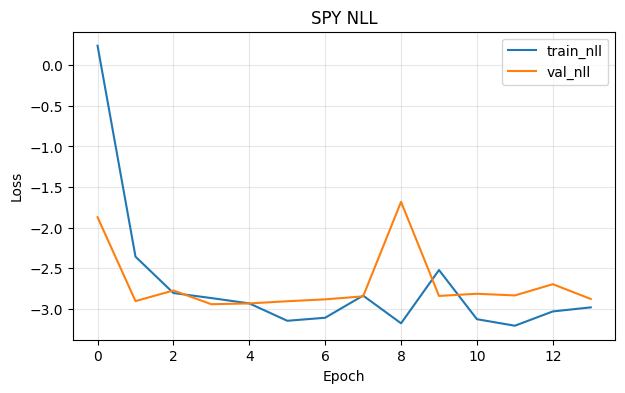

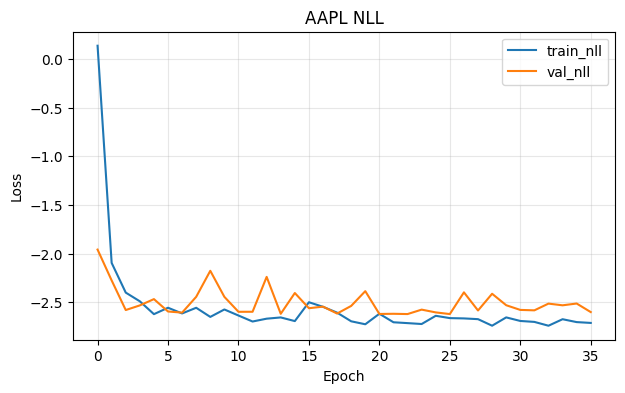

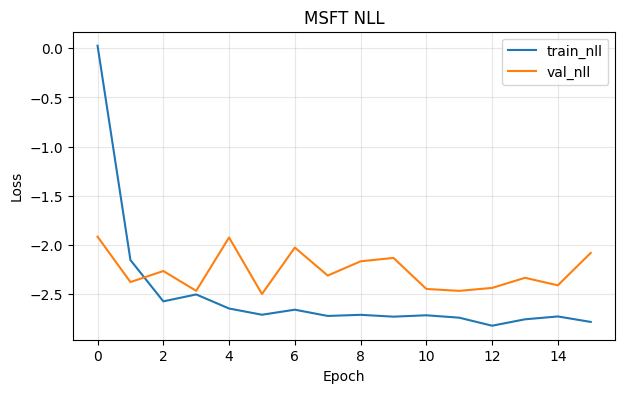

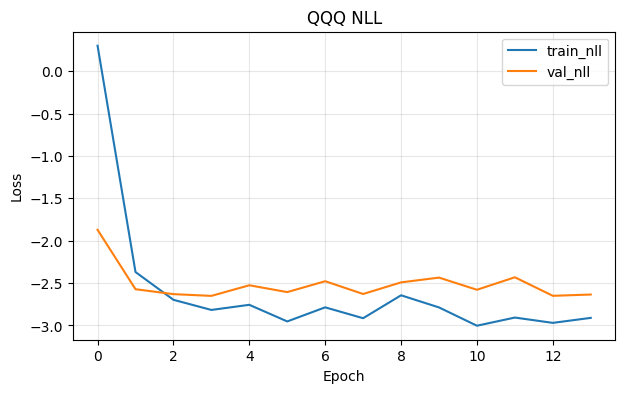

In [26]:
for ticker, hist in history_store.items():
    plt.figure(figsize=(7, 4))
    plt.plot(hist["train"], label="train_nll")
    plt.plot(hist["val"], label="val_nll")
    plt.title(f"{ticker} NLL")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 7) Run Inference On Test Window
Generate predicted Student-t parameters and ITM probabilities for each test date.

In [27]:
test_start = (pd.Timestamp(config.VAL_END) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
inference_store: dict[str, pd.DataFrame] = {}

for ticker, model in model_store.items():
    inference_store[ticker] = run_inference(
        model=model,
        ticker=ticker,
        features=feature_store[ticker],
        close_prices=raw_data[ticker]["Close"],
        lookback=config.LOOKBACK_WINDOW,
        test_start=test_start,
    )

{k: v.shape for k, v in inference_store.items()}

{'SPY': (501, 9), 'AAPL': (501, 9), 'MSFT': (501, 9), 'QQQ': (501, 9)}

# 8) Generate Directional Signals
Apply the probability threshold to produce BUY_CALL, BUY_PUT, or NO_TRADE.

In [28]:
signals_store: dict[str, pd.DataFrame] = {}
for ticker, inf_df in inference_store.items():
    signals_store[ticker] = generate_signals(
        inference_df=inf_df,
        threshold=config.ITM_PROB_THRESHOLD,
    )

{k: v["signal"].value_counts().to_dict() for k, v in signals_store.items()}

{'SPY': {'NO_TRADE': 331, 'BUY_PUT': 158, 'BUY_CALL': 12},
 'AAPL': {'NO_TRADE': 460, 'BUY_CALL': 28, 'BUY_PUT': 13},
 'MSFT': {'NO_TRADE': 367, 'BUY_CALL': 82, 'BUY_PUT': 52},
 'QQQ': {'NO_TRADE': 490, 'BUY_CALL': 9, 'BUY_PUT': 2}}

# 9) Backtest Per Ticker
Run a synthetic ATM options backtest for each ticker.

In [29]:
backtest_store: dict[str, pd.DataFrame] = {}
summary_store: dict[str, dict[str, float]] = {}

for ticker, sig_df in signals_store.items():
    results_df, summary = run_backtest(
        signals_df=sig_df,
        prices_by_ticker={ticker: raw_data[ticker]},
        expiry_days=config.SYNTHETIC_EXPIRY_DAYS,
        risk_free_rate=config.RISK_FREE_RATE,
    )
    backtest_store[ticker] = results_df
    summary_store[ticker] = summary

summary_store

{'SPY': {'n_trades': 167,
  'win_rate': 0.25149700598802394,
  'total_pnl': -44.960044398068675,
  'avg_pnl': -0.2692218227429262,
  'max_drawdown': -140.56142087544274},
 'AAPL': {'n_trades': 40,
  'win_rate': 0.425,
  'total_pnl': 28.66999633025759,
  'avg_pnl': 0.7167499082564397,
  'max_drawdown': -39.73576451131055},
 'MSFT': {'n_trades': 134,
  'win_rate': 0.3283582089552239,
  'total_pnl': -21.308246580693947,
  'avg_pnl': -0.15901676552756677,
  'max_drawdown': -128.841616524017},
 'QQQ': {'n_trades': 11,
  'win_rate': 0.7272727272727273,
  'total_pnl': 111.84747407539311,
  'avg_pnl': 10.167952188672102,
  'max_drawdown': -23.070852521714926}}

# 10) Plot Calibration Curves
Compare predicted call ITM probabilities with realized ITM frequencies.

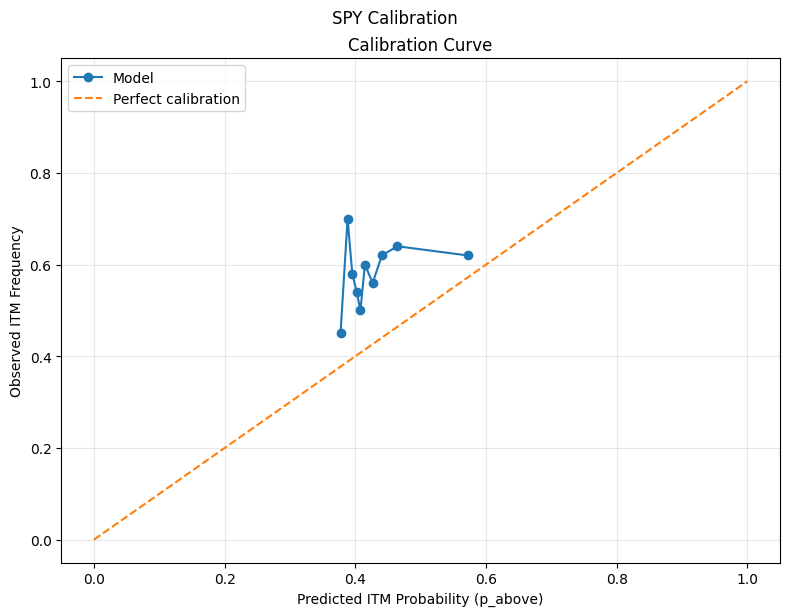

,bucket,predicted,actual,count
0,"(0.363, 0.384]",0.377440,0.45098,51
1,"(0.384, 0.393]",0.388176,0.70000,50
2,"(0.393, 0.399]",0.395405,0.58000,50
3,"(0.399, 0.405]",0.402137,0.54000,50
4,"(0.405, 0.41]",0.407860,0.50000,50
5,"(0.41, 0.419]",0.414713,0.60000,50
6,"(0.419, 0.433]",0.426546,0.56000,50
7,"(0.433, 0.45]",0.440651,0.62000,50
8,"(0.45, 0.481]",0.464548,0.64000,50
9,"(0.481, 0.892]",0.572021,0.62000,50


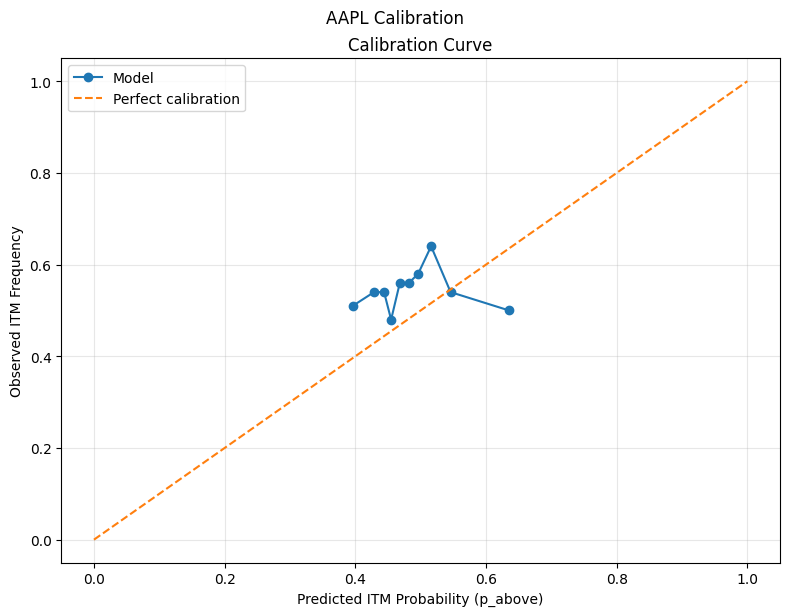

,bucket,predicted,actual,count
0,"(0.13, 0.419]",0.395851,0.509804,51
1,"(0.419, 0.438]",0.428655,0.540000,50
2,"(0.438, 0.449]",0.444042,0.540000,50
3,"(0.449, 0.461]",0.454814,0.480000,50
4,"(0.461, 0.474]",0.468137,0.560000,50
5,"(0.474, 0.489]",0.481994,0.560000,50
6,"(0.489, 0.506]",0.496201,0.580000,50
7,"(0.506, 0.526]",0.516014,0.640000,50
8,"(0.526, 0.566]",0.545865,0.540000,50
9,"(0.566, 0.879]",0.635327,0.500000,50


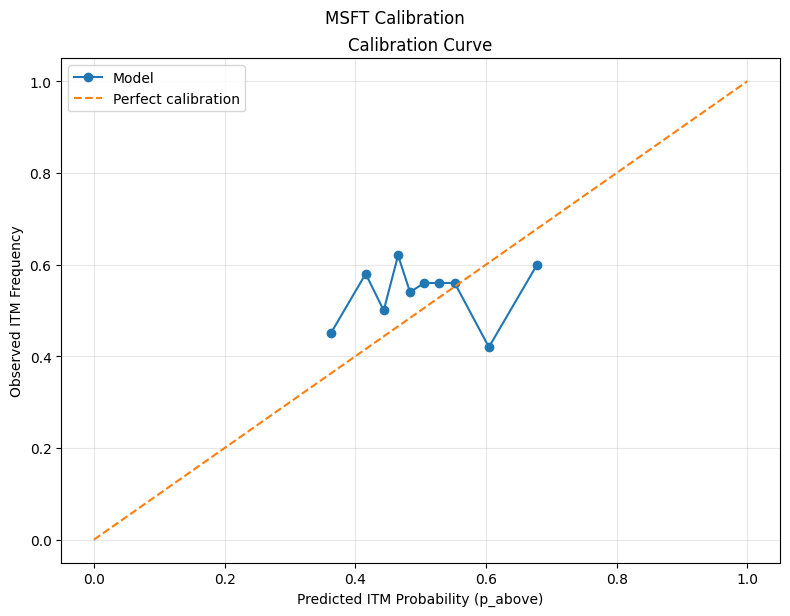

,bucket,predicted,actual,count
0,"(0.196, 0.399]",0.362830,0.45098,51
1,"(0.399, 0.429]",0.415925,0.58000,50
2,"(0.429, 0.457]",0.443455,0.50000,50
3,"(0.457, 0.474]",0.465476,0.62000,50
4,"(0.474, 0.493]",0.483749,0.54000,50
5,"(0.493, 0.518]",0.505550,0.56000,50
6,"(0.518, 0.537]",0.527479,0.56000,50
7,"(0.537, 0.568]",0.552074,0.56000,50
8,"(0.568, 0.63]",0.604469,0.42000,50
9,"(0.63, 0.818]",0.678247,0.60000,50


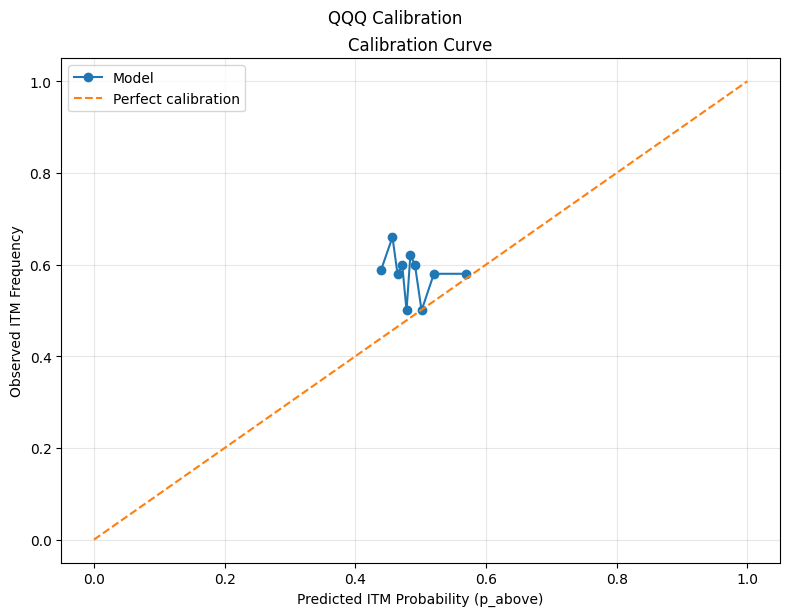

,bucket,predicted,actual,count
0,"(0.254, 0.453]",0.439410,0.588235,51
1,"(0.453, 0.46]",0.456879,0.660000,50
2,"(0.46, 0.469]",0.464595,0.580000,50
3,"(0.469, 0.475]",0.471755,0.600000,50
4,"(0.475, 0.481]",0.478438,0.500000,50
5,"(0.481, 0.487]",0.484253,0.620000,50
6,"(0.487, 0.494]",0.491215,0.600000,50
7,"(0.494, 0.509]",0.501434,0.500000,50
8,"(0.509, 0.533]",0.520304,0.580000,50
9,"(0.533, 0.716]",0.569939,0.580000,50


In [30]:
for ticker, sig_df in signals_store.items():
    test_actuals = target_store[ticker].loc[target_store[ticker].index >= pd.Timestamp(test_start)]
    fig, stats = calibration_curve(sig_df, test_actuals)
    fig.suptitle(f"{ticker} Calibration", y=1.02)
    plt.show()
    display(stats)

# 11) Plot PnL Curves
Visualize cumulative PnL and drawdown for each ticker.

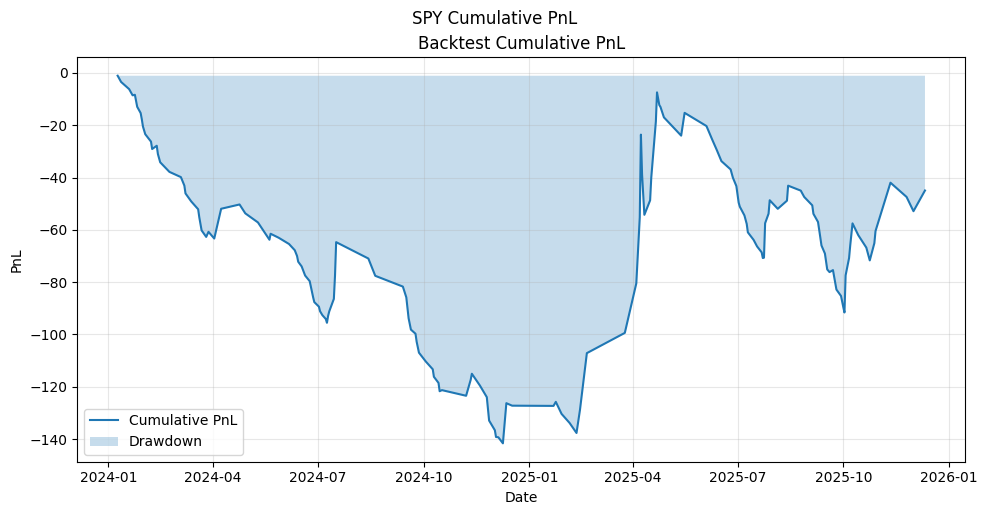

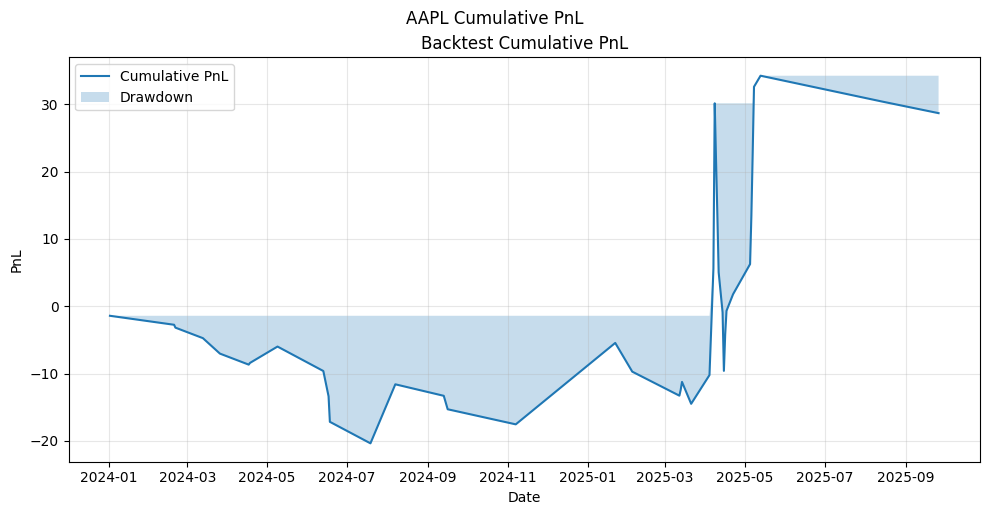

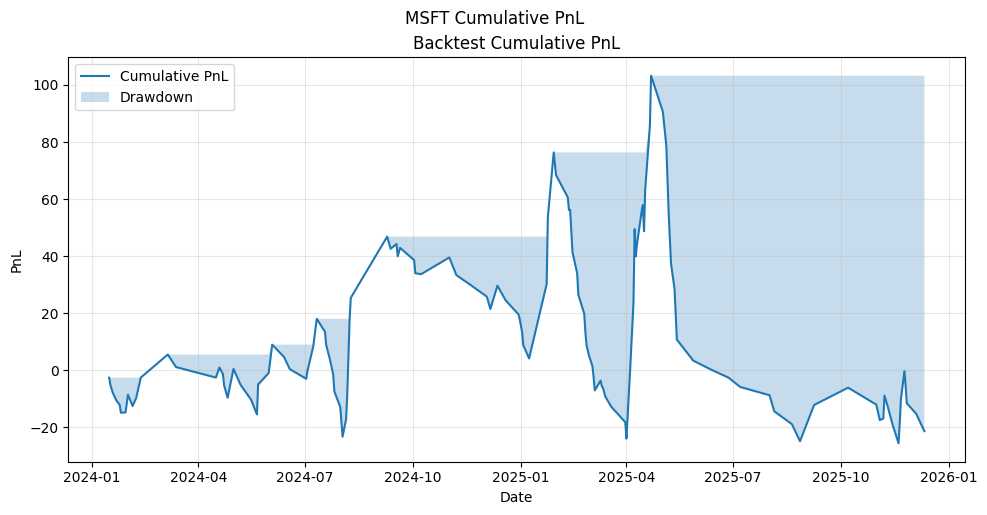

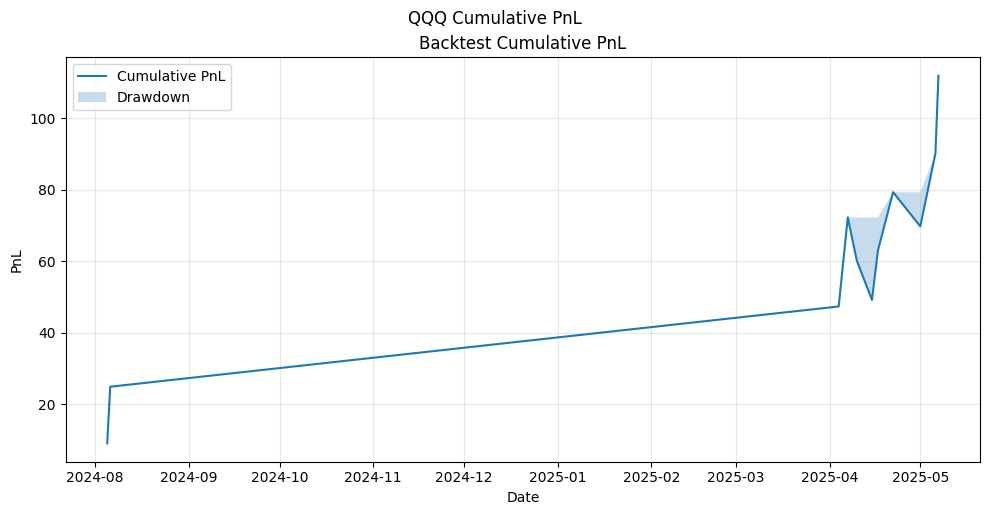

In [31]:
for ticker, bt_df in backtest_store.items():
    fig = plot_pnl(bt_df)
    fig.suptitle(f"{ticker} Cumulative PnL", y=1.02)
    plt.show()

# 12) Aggregate Across Tickers
Combine all trades and report overall backtest statistics.

In [32]:
all_signals = pd.concat(signals_store.values(), ignore_index=True) if signals_store else pd.DataFrame()
all_backtests = pd.concat(backtest_store.values(), ignore_index=True) if backtest_store else pd.DataFrame()

if not all_backtests.empty:
    all_backtests = all_backtests.sort_values("date")
    all_backtests["cum_pnl"] = all_backtests["pnl"].cumsum()
    overall = {
        "n_trades": int(len(all_backtests)),
        "win_rate": float((all_backtests["pnl"] > 0.0).mean()),
        "total_pnl": float(all_backtests["pnl"].sum()),
        "avg_pnl": float(all_backtests["pnl"].mean()),
        "max_drawdown": float((all_backtests["cum_pnl"] - all_backtests["cum_pnl"].cummax()).min()),
    }
else:
    overall = {"n_trades": 0, "win_rate": 0.0, "total_pnl": 0.0, "avg_pnl": 0.0, "max_drawdown": 0.0}

overall

{'n_trades': 352,
 'win_rate': 0.3153409090909091,
 'total_pnl': 74.24917942688805,
 'avg_pnl': 0.2109351688263865,
 'max_drawdown': -140.07035477508677}

# 13) Build Realized Option Outcomes
Join inference outputs with realized expiry prices to compute actual ITM outcomes for calls and puts.

In [34]:
outcomes_store: dict[str, pd.DataFrame] = {}
for ticker, inf_df in inference_store.items():
    outcomes_store[ticker] = prepare_option_outcomes(
        inference_df=inf_df,
        prices_by_ticker={ticker: raw_data[ticker]},
        expiry_days=config.SYNTHETIC_EXPIRY_DAYS,
    )

{k: v.shape for k, v in outcomes_store.items()}

{'SPY': (496, 15), 'AAPL': (496, 15), 'MSFT': (496, 15), 'QQQ': (496, 15)}

# 14) Inspect Actual Outcome Data
Display concrete rows with predicted probabilities, realized returns, and actual ITM labels.

In [35]:
for ticker, outcomes_df in outcomes_store.items():
    print(f"\n{ticker} sample rows:")
    display(
        outcomes_df[
            [
                "date",
                "expiry_date",
                "spot_t",
                "spot_T",
                "mu",
                "sigma",
                "nu",
                "p_above",
                "p_below",
                "realized_log_return",
                "actual_call_itm",
                "actual_put_itm",
            ]
        ].head(10)
    )


SPY sample rows:


,date,expiry_date,spot_t,spot_T,mu,sigma,nu,p_above,p_below,realized_log_return,actual_call_itm,actual_put_itm
0,2024-01-02,2024-01-09,459.991211,461.188263,-0.002379,0.009538,2.5,0.411035,0.588965,0.002599,True,False
1,2024-01-03,2024-01-10,456.234619,463.796509,-0.002353,0.009531,2.5,0.411913,0.588087,0.016439,True,False
2,2024-01-04,2024-01-11,454.765015,463.592133,-0.002211,0.009541,2.5,0.417178,0.582822,0.019224,True,False
3,2024-01-05,2024-01-12,455.387909,463.913269,-0.002405,0.009562,2.5,0.410317,0.589683,0.018548,True,False
4,2024-01-08,2024-01-16,461.889008,462.210114,-0.002476,0.009580,2.5,0.407898,0.592102,0.000695,True,False
5,2024-01-09,2024-01-17,461.188263,459.640869,-0.003014,0.009594,2.5,0.388871,0.611129,-0.003361,False,True
6,2024-01-10,2024-01-18,463.796509,463.728394,-0.002035,0.009597,2.5,0.424063,0.575937,-0.000147,False,True
7,2024-01-11,2024-01-19,463.592133,469.509308,-0.002688,0.009575,2.5,0.400234,0.599766,0.012683,True,False
8,2024-01-12,2024-01-22,463.913269,470.502014,-0.002725,0.009563,2.5,0.398794,0.601206,0.014103,True,False
9,2024-01-16,2024-01-23,462.210114,471.874176,-0.002406,0.009573,2.5,0.410375,0.589625,0.020693,True,False



AAPL sample rows:


,date,expiry_date,spot_t,spot_T,mu,sigma,nu,p_above,p_below,realized_log_return,actual_call_itm,actual_put_itm
0,2024-01-02,2024-01-09,183.731308,183.236450,-0.002659,0.008948,2.5,0.394650,0.605350,-0.002697,False,True
1,2024-01-03,2024-01-10,182.355576,184.275650,-0.002074,0.010557,2.5,0.429551,0.570449,0.010474,True,False
2,2024-01-04,2024-01-11,180.039673,183.681793,0.001037,0.011610,2.5,0.532256,0.467744,0.020028,True,False
3,2024-01-05,2024-01-12,179.317154,184.008438,0.001114,0.012331,2.5,0.532636,0.467364,0.025826,True,False
4,2024-01-08,2024-01-16,183.652130,181.741989,-0.000859,0.012490,2.5,0.475158,0.524842,-0.010455,False,True
5,2024-01-09,2024-01-17,183.236450,180.801727,-0.000405,0.012116,2.5,0.487905,0.512095,-0.013376,False,True
6,2024-01-10,2024-01-18,184.275650,186.690552,-0.002130,0.011170,2.5,0.431582,0.568418,0.013020,True,False
7,2024-01-11,2024-01-19,183.681793,189.590454,-0.001508,0.010877,2.5,0.450050,0.549950,0.031661,True,False
8,2024-01-12,2024-01-22,184.008438,191.896469,-0.000276,0.010602,2.5,0.490596,0.509404,0.041974,True,False
9,2024-01-16,2024-01-23,181.741989,193.173203,-0.001185,0.010258,2.5,0.458325,0.541675,0.060999,True,False



MSFT sample rows:


,date,expiry_date,spot_t,spot_T,mu,sigma,nu,p_above,p_below,realized_log_return,actual_call_itm,actual_put_itm
0,2024-01-02,2024-01-09,364.589417,369.426117,-0.000498,0.010235,2.5,0.482405,0.517595,0.013179,True,False
1,2024-01-03,2024-01-10,364.324036,376.287903,0.001560,0.010271,2.5,0.554663,0.445337,0.032311,True,False
2,2024-01-04,2024-01-11,361.709076,378.116425,0.000843,0.010261,2.5,0.529663,0.470337,0.044362,True,False
3,2024-01-05,2024-01-12,361.522308,381.891388,0.001110,0.010301,2.5,0.538873,0.461127,0.054812,True,False
4,2024-01-08,2024-01-16,368.344788,383.660950,0.001121,0.010341,2.5,0.539099,0.460901,0.040740,True,False
5,2024-01-09,2024-01-17,369.426117,382.874451,-0.002069,0.010318,2.5,0.428122,0.571878,0.035756,True,False
6,2024-01-10,2024-01-18,376.287903,387.199951,-0.001104,0.010310,2.5,0.461364,0.538636,0.028587,True,False
7,2024-01-11,2024-01-19,378.116425,391.918671,-0.002780,0.010230,2.5,0.403336,0.596664,0.035852,True,False
8,2024-01-12,2024-01-22,381.891388,389.795288,-0.002478,0.010148,2.5,0.412844,0.587156,0.020485,True,False
9,2024-01-16,2024-01-23,383.660950,392.144745,-0.002901,0.010083,2.5,0.397874,0.602126,0.021872,True,False



QQQ sample rows:


,date,expiry_date,spot_t,spot_T,mu,sigma,nu,p_above,p_below,realized_log_return,actual_call_itm,actual_put_itm
0,2024-01-02,2024-01-09,397.690765,400.812286,-0.000390,0.009408,2.5,0.485013,0.514987,0.007818,True,False
1,2024-01-03,2024-01-10,393.482666,403.528839,0.000079,0.009441,2.5,0.503046,0.496954,0.025211,True,False
2,2024-01-04,2024-01-11,391.457520,404.368500,-0.000019,0.009483,2.5,0.499277,0.500723,0.032450,True,False
3,2024-01-05,2024-01-12,391.921875,404.575928,-0.000145,0.009536,2.5,0.494498,0.505502,0.031777,True,False
4,2024-01-08,2024-01-16,400.022064,404.536407,-0.000245,0.009555,2.5,0.490715,0.509285,0.011222,True,False
5,2024-01-09,2024-01-17,400.812286,402.254547,-0.000963,0.009591,2.5,0.463766,0.536234,0.003592,True,False
6,2024-01-10,2024-01-18,403.528839,407.964172,-0.000770,0.009574,2.5,0.470960,0.529040,0.010931,True,False
7,2024-01-11,2024-01-19,404.368500,416.054504,-0.000952,0.009497,2.5,0.463809,0.536191,0.028490,True,False
8,2024-01-12,2024-01-22,404.575928,416.597839,-0.001125,0.009456,2.5,0.457089,0.542911,0.029282,True,False
9,2024-01-16,2024-01-23,404.536407,418.326538,-0.000804,0.009458,2.5,0.469290,0.530710,0.033521,True,False


# 15) Plot Predicted Distribution Vs Realized Outcome
For each ticker, plot one snapshot of the predicted Student-t distribution and the realized return at expiry.

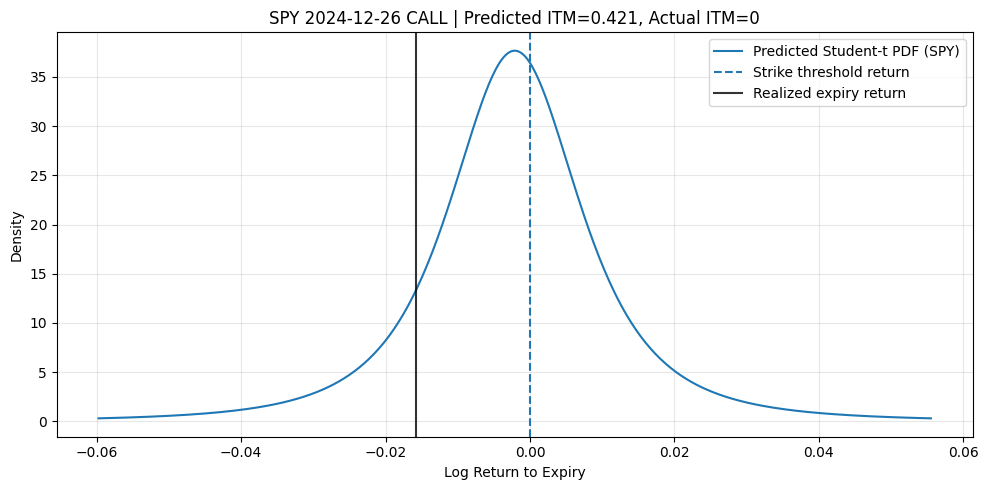

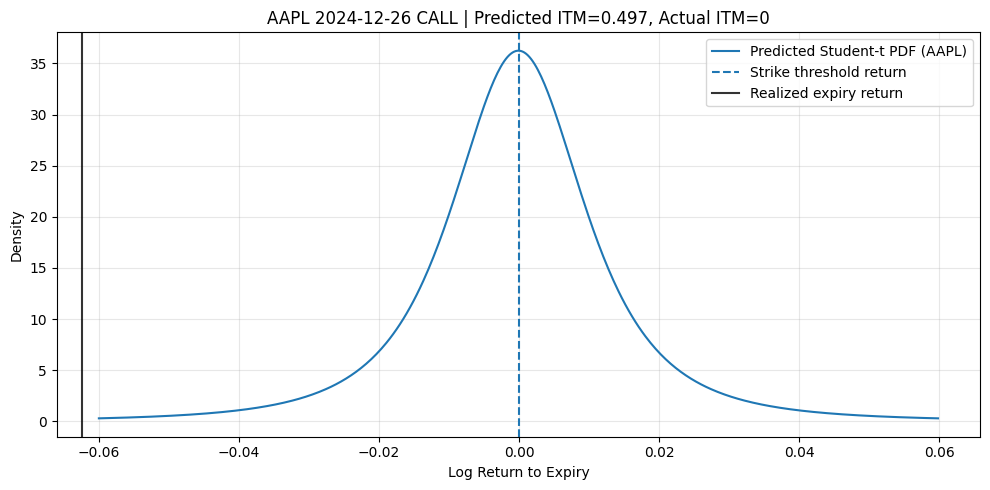

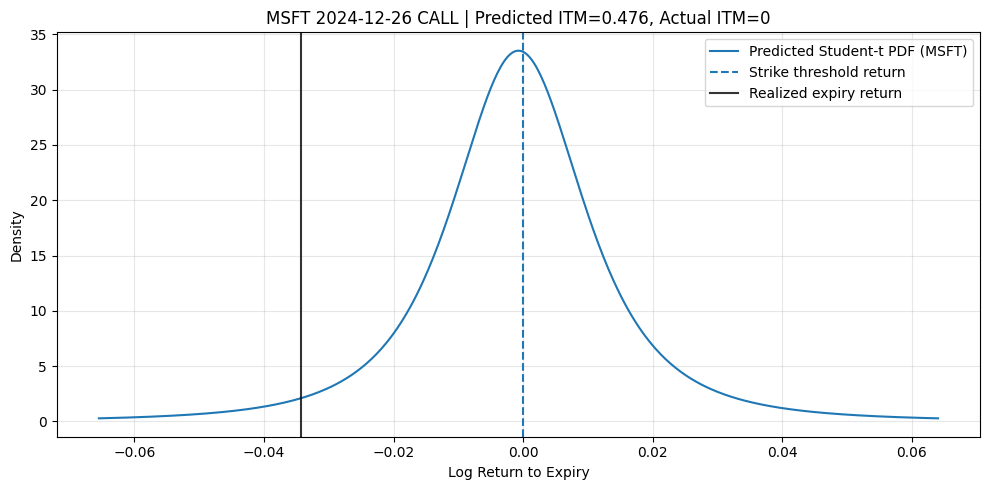

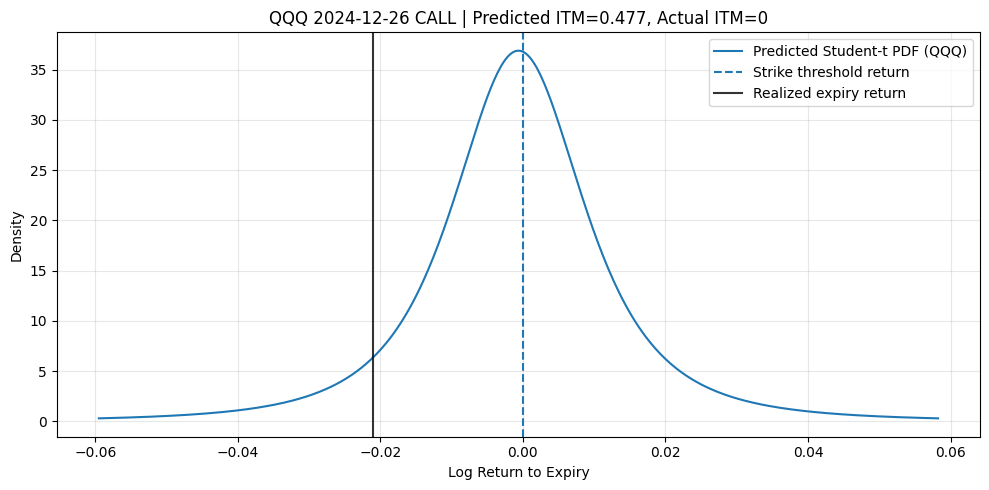

In [36]:
for ticker, outcomes_df in outcomes_store.items():
    if outcomes_df.empty:
        continue
    sample_date = outcomes_df.iloc[len(outcomes_df) // 2]["date"]
    fig = plot_distribution_snapshot(
        outcomes_df=outcomes_df,
        ticker=ticker,
        asof_date=sample_date,
        option_type="call",
    )
    plt.show()

# 16) Plot Predicted Probability Vs Actual ITM Frequency
For each ticker and option side, compare predicted ITM probability to rolling realized ITM frequency.

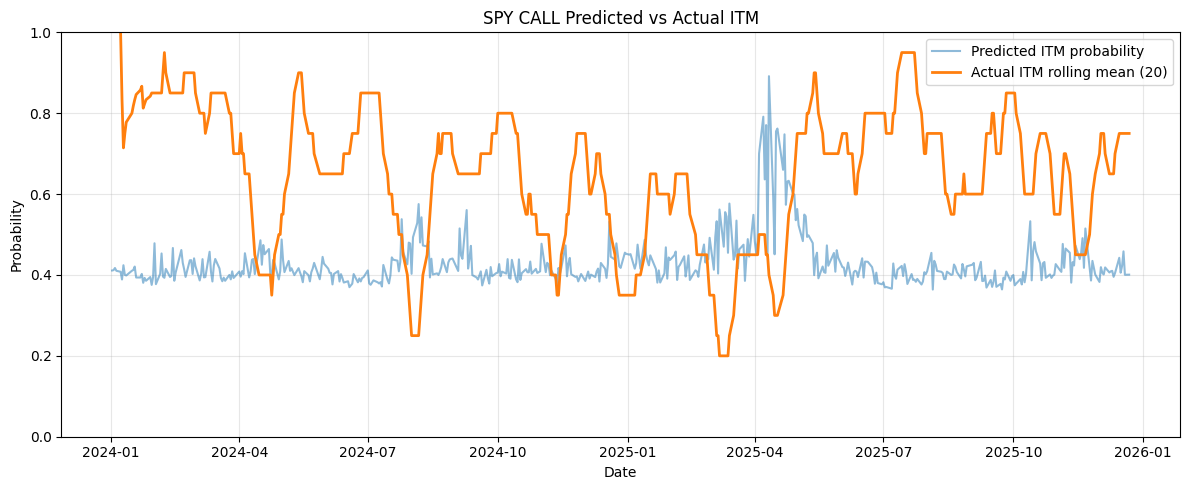

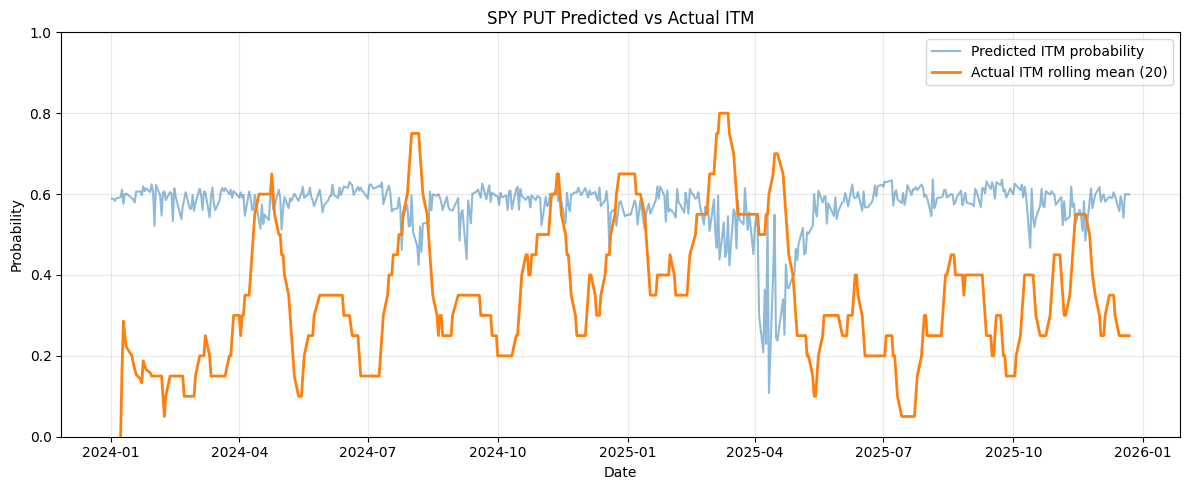

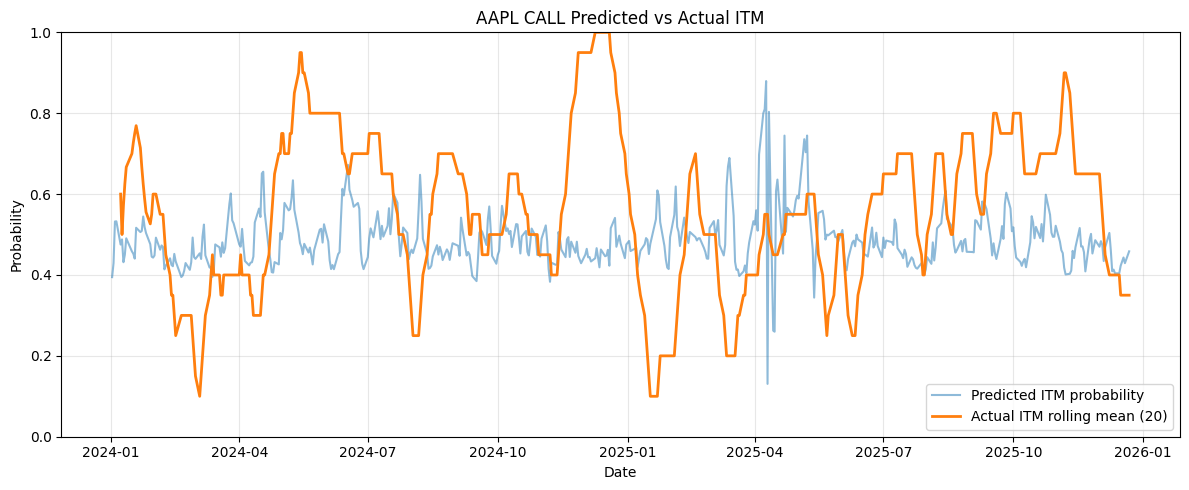

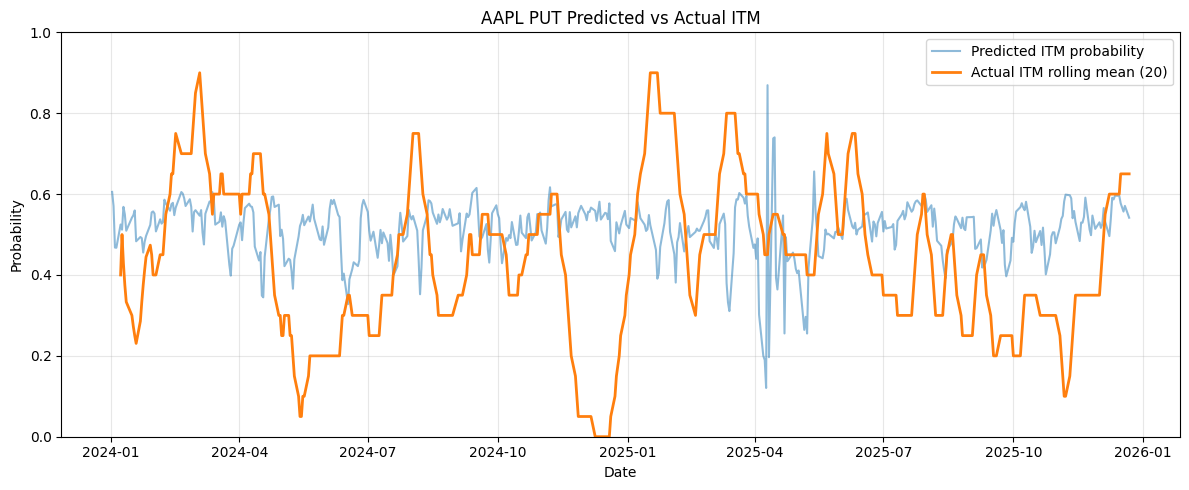

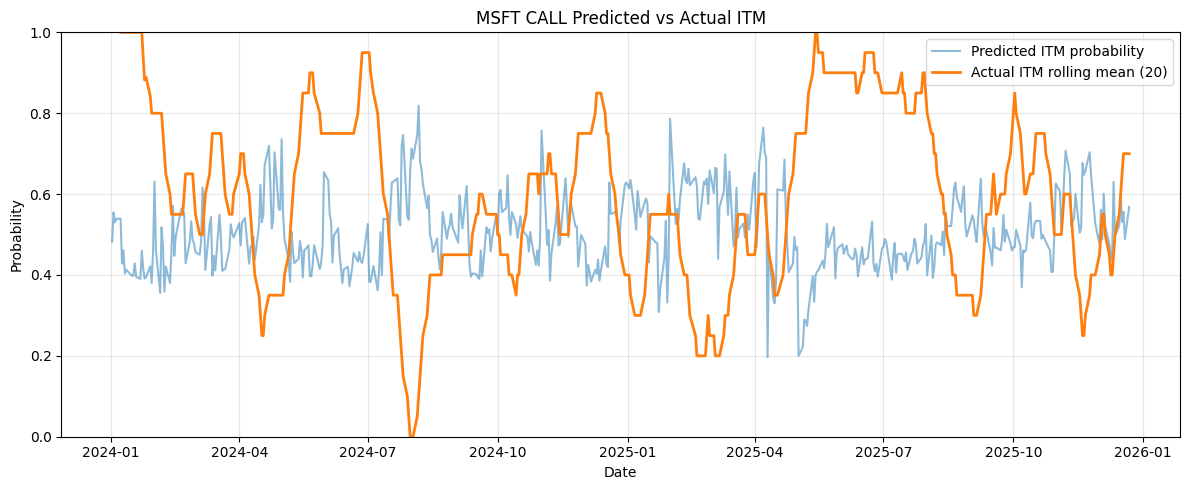

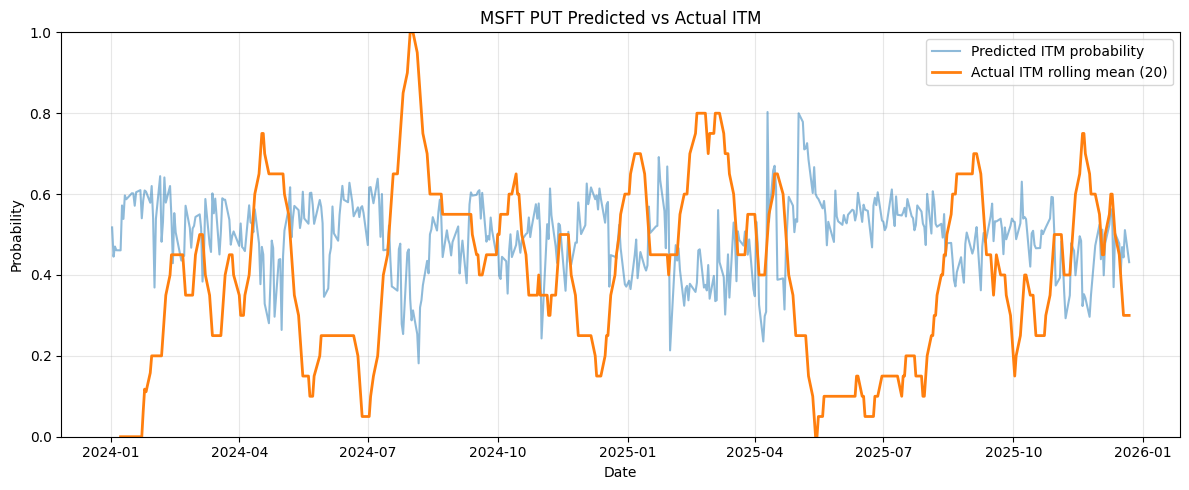

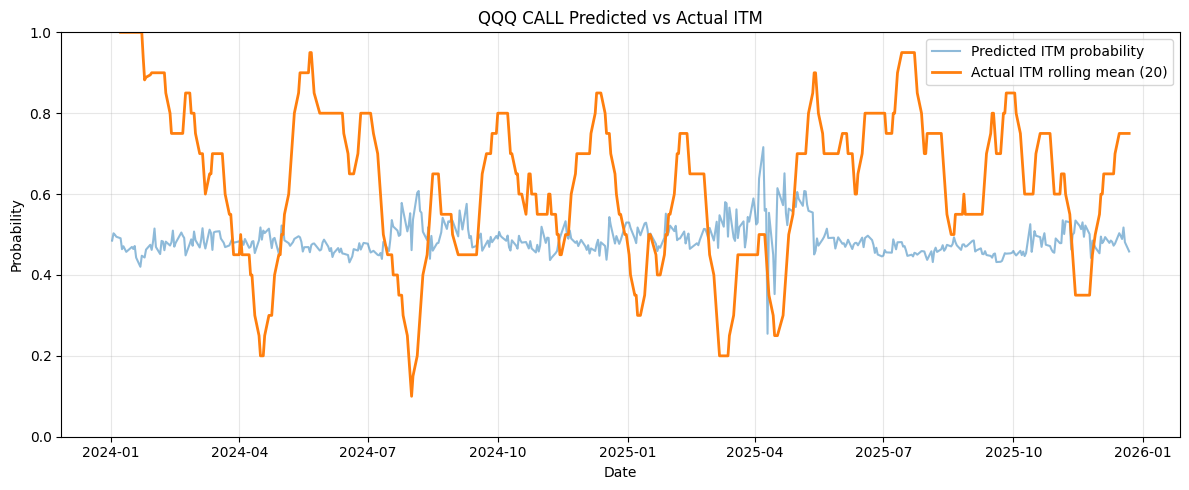

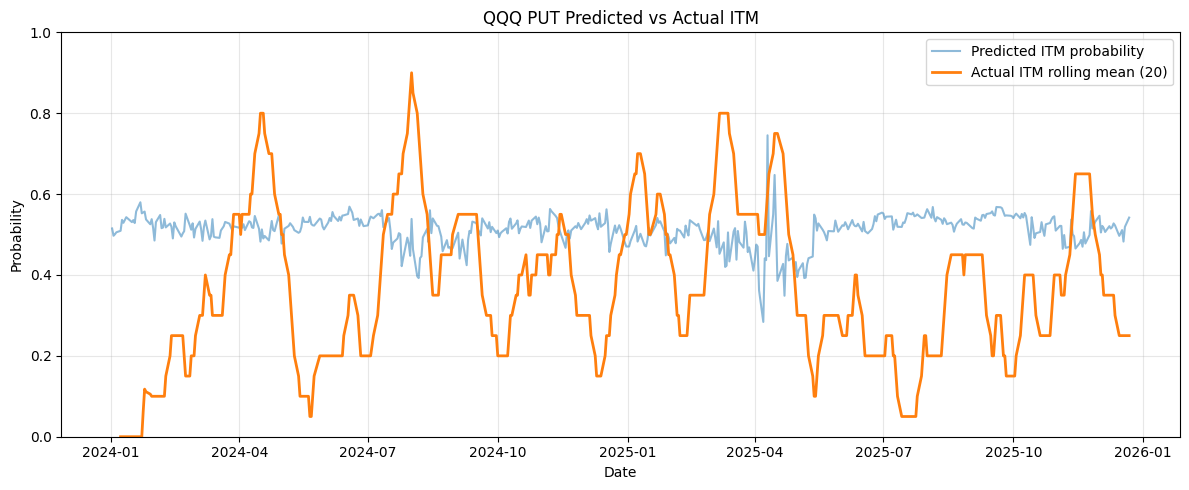

In [37]:
for ticker, outcomes_df in outcomes_store.items():
    if outcomes_df.empty:
        continue

    fig_call = plot_probability_vs_actual(
        outcomes_df=outcomes_df,
        ticker=ticker,
        option_type="call",
        rolling_window=20,
    )
    plt.show()

    fig_put = plot_probability_vs_actual(
        outcomes_df=outcomes_df,
        ticker=ticker,
        option_type="put",
        rolling_window=20,
    )
    plt.show()

# 17) Plot Realized Vs Predicted Returns
Scatter predicted mean return against realized log return to inspect directional fit.

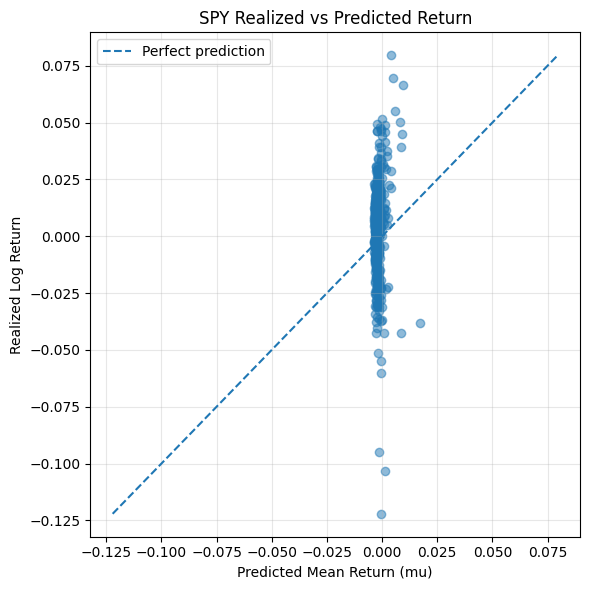

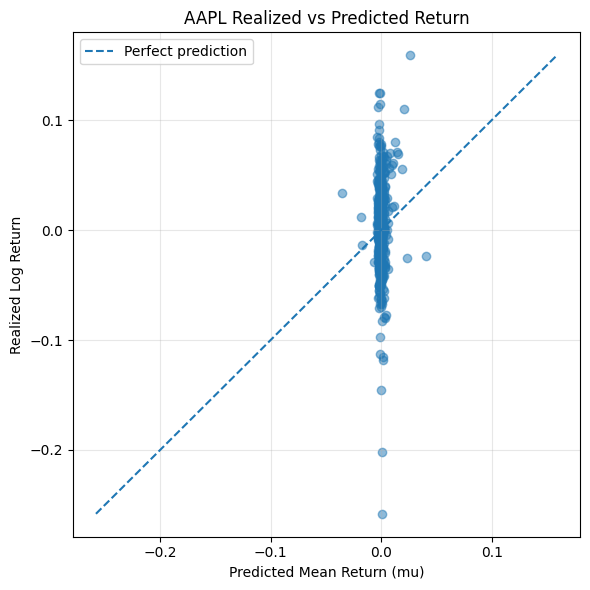

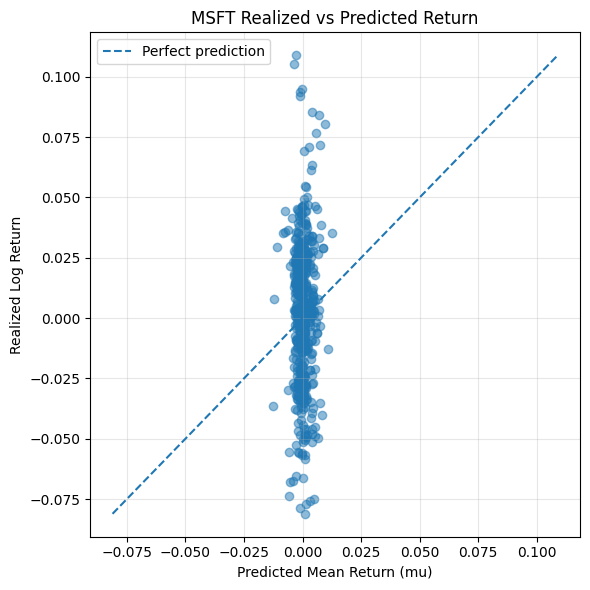

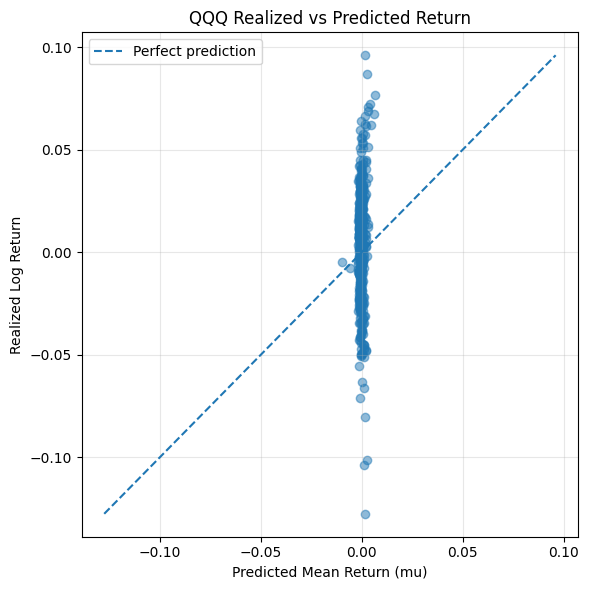

In [38]:
for ticker, outcomes_df in outcomes_store.items():
    if outcomes_df.empty:
        continue
    fig = plot_realized_vs_predicted_returns(outcomes_df=outcomes_df, ticker=ticker)
    plt.show()